# ♟️ MicroCNN Domain Classifier Training & Benchmarking Notebook

**Target:** Train, validate, and test an ultra-compact **MicroCNN** neural classifier ($< 1.5\text{ MB}$ ONNX, sub-$2.5\text{ ms}$ CPU inference, sub-$0.4\text{ ms}$ GPU inference, $>99.5\%$ accuracy) for **US-3.1.2**.

### Dataset Splits & Pipeline Strategy:
- **Train Set (70% real images / 6,000 samples)**: Parameter optimization with GPU mixed precision.
- **Validation Set (15% real images / 1,200 samples)**: Cosine annealing learning rate scheduling and live metric tracking.
- **Held-Out Test Set (15% real images / 1,200 samples)**: Unbiased post-training evaluation across real camera photos, digital themes, JPEG artifacts, and Moiré screen recaptures with Confusion Matrix.
- **Tier-1 Fast Path ($<0.4\text{ ms}$)**: Multi-feature statistical screener ($H_{\text{norm}}, ZNR, AGE, LH$).
- **Tier-2 Neural Fallback ($<0.5\text{ ms}$)**: MicroCNN triggered when Tier-1 confidence is ambiguous ($0.20 \le S \le 0.80$).

In [1]:
# 1. Environment, Autoreload & GPU Hardware Initialization
%load_ext autoreload
%autoreload 2

import os
import sys
import shutil
import importlib
from pathlib import Path

# Ensure project root is detected and set as current working directory
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import math
import random
import time
import cv2
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from IPython.display import display

import src.domain_classifier.train_micro_cnn as train_module
importlib.reload(train_module)
from src.domain_classifier.train_micro_cnn import (
    generate_synthetic_digital_board,
    generate_synthetic_physical_photo,
    generate_synthetic_screen_recapture,
    apply_jpeg_compression,
    ChessDomainDataset,
)
from src.dataset import DatasetRegistry
from src.domain_classifier.micro_cnn import MicroCNN, build_domain_classifier_model
from src.domain_classifier.neural_classifier import NeuralDomainClassifier
from src.schemas.contracts import DomainType

# Hardware Acceleration Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # Enable fast cuDNN kernel autotuning
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"[Setup] 🚀 GPU Acceleration ACTIVE: {gpu_name} ({vram_gb:.2f} GB VRAM)")
    print(f"[Setup] CUDA Version: {torch.version.cuda}, cuDNN: {torch.backends.cudnn.version()}")
else:
    print("[Setup] Running on CPU")

print(f"[Setup] Project Root: {project_root.resolve()}")
print(f"[Setup] ONNX Runtime Available Providers: {ort.get_available_providers()}")

[Setup] 🚀 GPU Acceleration ACTIVE: NVIDIA GeForce RTX 5060 Ti (15.93 GB VRAM)
[Setup] CUDA Version: 12.8, cuDNN: 91900
[Setup] Project Root: C:\coding\chess_ml
[Setup] ONNX Runtime Available Providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


## 2. Ingesting Real Physical Camera Dataset with `tqdm`

Run the cell below to download thousands of **real-world physical camera photos** of wooden/plastic chessboards (`real_physical_boards`, ~213 MB from Hugging Face / Roboflow) with live byte-level and extraction `tqdm` progress bars, standardizing them into `data/standardized/physical/images/`.

In [7]:
import shutil
from pathlib import Path
from tqdm.auto import tqdm
from src.dataset import DatasetRegistry

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# 1. Download Real Physical Camera Photographs Dataset (~213 MB)
print("📥 Downloading Real Physical Camera Photographs Dataset (213 MB):")
phys_dl = DatasetRegistry.get_downloader("real_physical_boards")
raw_phys_dir = phys_dl.download(project_root / "data" / "raw" / "physical")

# 2. Standardize Real Physical Images into data/standardized/physical/images
standardized_phys_dir = project_root / "data" / "standardized" / "physical" / "images"
standardized_phys_dir.mkdir(parents=True, exist_ok=True)

# Scan extracted raw images across all splits
raw_images = list(raw_phys_dir.rglob("*.jpg")) + list(raw_phys_dir.rglob("*.png"))
print(f"\n📦 Discovered {len(raw_images)} real camera photos in {raw_phys_dir}")

for img_path in tqdm(raw_images, desc="Standardizing Real Physical Images", unit="img"):
    dest_path = standardized_phys_dir / f"real_{img_path.name}"
    if not dest_path.exists():
        shutil.copy2(img_path, dest_path)

digital_dir = project_root / "data" / "standardized" / "digital" / "images"
physical_dir = standardized_phys_dir

real_digital_files = list(digital_dir.glob("*.*")) if digital_dir.is_dir() else []
real_physical_files = list(physical_dir.glob("*.*")) if physical_dir.is_dir() else []

print(f"\n✅ Total Standardized Digital Images: {len(real_digital_files)}")
print(f"✅ Total Standardized Real Physical Images: {len(real_physical_files)}")

📥 Downloading Real Physical Camera Photographs Dataset (213 MB):


📦 Extracting chessboard-dataset-yolo.zip:   0%|          | 0/7369 [00:00<?, ?file/s]


📦 Discovered 3680 real camera photos in c:\coding\chess_ml\data\raw\physical\real_physical_boards


Standardizing Real Physical Images:   0%|          | 0/3680 [00:00<?, ?img/s]


✅ Total Standardized Digital Images: 250
✅ Total Standardized Real Physical Images: 3680


## 3. Visualizing Real Physical Photos & Edge-Case Generators

Let's visualize the 4 key categories:
1. **Clean Digital Boards** (Chess.com, Lichess, wood/marble themes)
2. **Compressed Digital Screenshots** (JPEG compression ringing)
3. **Real Physical Camera Photos** (actual wooden/plastic boards, shadows, room lighting)
4. **Monitor Screen Recaptures with Moiré** (interference fringes, bezel glare)

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Digital samples (Class 0: DIGITAL_2D)
for i in range(2):
    img_d = generate_synthetic_digital_board(size=128)
    axes[0, i].imshow(cv2.cvtColor(img_d, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title("Digital 2D: Clean/Themed")
    axes[0, i].axis("off")

for i in range(2, 4):
    img_d_jpeg = apply_jpeg_compression(generate_synthetic_digital_board(size=128), quality=30)
    axes[0, i].imshow(cv2.cvtColor(img_d_jpeg, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title("Digital 2D: JPEG Ringing (Q=30)")
    axes[0, i].axis("off")

# Physical samples (Class 1: PHYSICAL_3D) - Real photos if available
for i in range(4):
    if real_physical_files and i < len(real_physical_files):
        sample_path = random.choice(real_physical_files)
        img_p = cv2.imread(str(sample_path))
        if img_p is not None:
            img_p = cv2.resize(img_p, (128, 128))
            axes[1, i].imshow(cv2.cvtColor(img_p, cv2.COLOR_BGR2RGB))
            axes[1, i].set_title(f"Real Physical 3D Photo\n({sample_path.name[:18]}...)", fontsize=10)
            axes[1, i].axis("off")
            continue
            
    # Fallback to generator if file not found
    img_p = generate_synthetic_physical_photo(size=128)
    axes[1, i].imshow(cv2.cvtColor(img_p, cv2.COLOR_BGR2RGB))
    axes[1, i].set_title("Physical 3D Photo")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## 4. MicroCNN Model Architecture & Parameter Inspection

In [8]:
model = MicroCNN(num_classes=2, dropout_rate=0.20).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 60)
print(f"  MicroCNN Total Trainable Parameters: {total_params:,}")
print(f"  Estimated FP32 ONNX Size: ~{total_params * 4 / (1024*1024):.2f} MB (< 1.5 MB limit)")
print(f"  Training Device: {device.type.upper()} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")
print("=" * 60)
print(model)

  MicroCNN Total Trainable Parameters: 112,234
  Estimated FP32 ONNX Size: ~0.43 MB (< 1.5 MB limit)
  Training Device: CUDA (NVIDIA GeForce RTX 5060 Ti)
MicroCNN(
  (stem): ConvBNAct(
    (block): Sequential(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
  )
  (stage2): Sequential(
    (0): InvertedResidualBlock(
      (conv): Sequential(
        (0): ConvBNAct(
          (block): Sequential(
            (0): Conv2d(24, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (1): ConvBNAct(
          (block): Sequential(
            (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=48, bias=False)
            (1): BatchNorm2d(48, eps=1e

## 5. GPU-Accelerated Training with Live Dynamic Dashboard

Configures explicit **70% Train / 15% Val / 15% Test** disjoint splits of real dataset images (`SPLIT_RATIOS = (0.70, 0.15, 0.15)` with `seed=42`), ensuring **zero data leakage** into the test evaluation.

[Dataset Split] Train Real Physical Images: 2576 (70%)
[Dataset Split] Val   Real Physical Images: 552 (15%)
[Dataset Split] Train Real Digital Images:  175 (70%)
[Dataset Split] Val   Real Digital Images:  37 (15%)


🚀 GPU Training Progress:   0%|          | 0/5 [00:00<?, ?epoch/s]

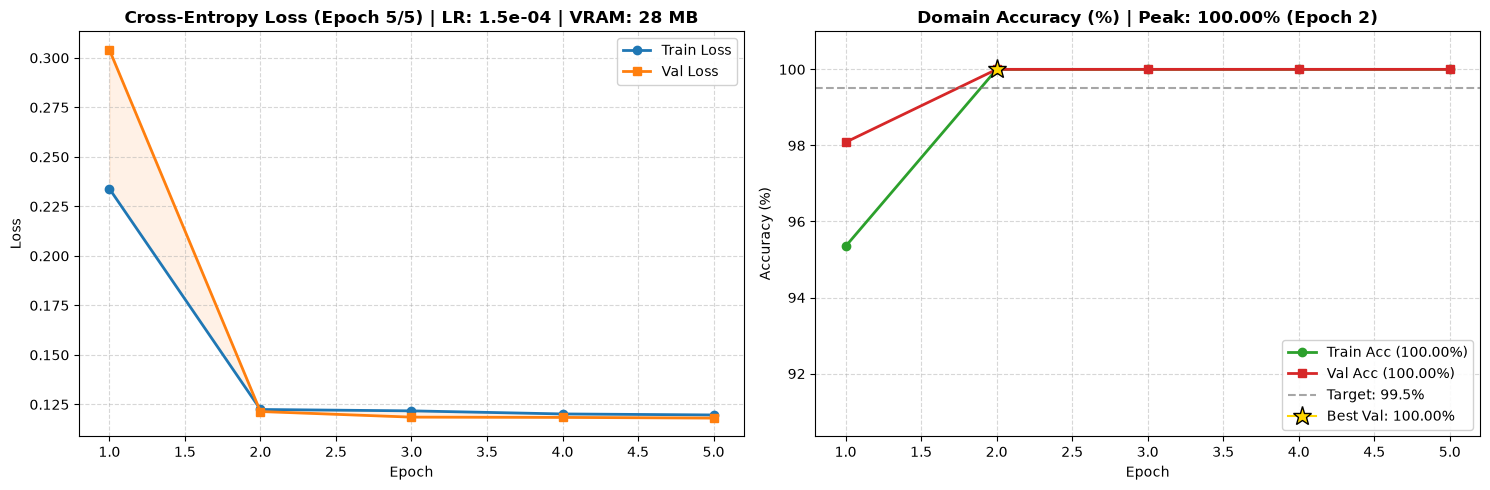

Epoch 01/05 [Train]:   0%|          | 0/46 [00:00<?, ?batch/s]

Epoch 02/05 [Train]:   0%|          | 0/46 [00:00<?, ?batch/s]

Epoch 03/05 [Train]:   0%|          | 0/46 [00:00<?, ?batch/s]

Epoch 04/05 [Train]:   0%|          | 0/46 [00:00<?, ?batch/s]

Epoch 05/05 [Train]:   0%|          | 0/46 [00:00<?, ?batch/s]


🚀 GPU Training Complete in 167.7s (33.54s/epoch) on NVIDIA GeForce RTX 5060 Ti!
🏆 Peak Validation Accuracy: 100.00%


In [9]:
import importlib
import src.domain_classifier.train_micro_cnn as train_module
importlib.reload(train_module)
from src.domain_classifier.train_micro_cnn import ChessDomainDataset

# ---------------------------------------------------------------------------
# 🎯 Train / Validation / Test Split Configuration (SSOT)
# ---------------------------------------------------------------------------
SPLIT_RATIOS = (0.70, 0.15, 0.15)  # 70% Train, 15% Validation, 15% Held-Out Test
SPLIT_SEED = 42                     # Deterministic seed for disjoint real image partitioning

NUM_TRAIN_SAMPLES = 6000
NUM_VAL_SAMPLES = 1200
BATCH_SIZE = 128  # Saturated batch size for 16GB VRAM
EPOCHS = 5
LEARNING_RATE = 1.5e-3

# 1. Train Dataset (70% Real Images + Procedural Augmentations)
train_dataset = ChessDomainDataset(
    num_samples=NUM_TRAIN_SAMPLES,
    real_digital_dir=digital_dir,
    real_physical_dir=physical_dir,
    split="train",
    split_ratios=SPLIT_RATIOS,
    seed=SPLIT_SEED,
)

# 2. Validation Dataset (15% Real Images + Procedural Augmentations)
val_dataset = ChessDomainDataset(
    num_samples=NUM_VAL_SAMPLES,
    real_digital_dir=digital_dir,
    real_physical_dir=physical_dir,
    split="val",
    split_ratios=SPLIT_RATIOS,
    seed=SPLIT_SEED,
)

print(f"[Dataset Split] Train Real Physical Images: {len(train_dataset.real_physical)} (70%)")
print(f"[Dataset Split] Val   Real Physical Images: {len(val_dataset.real_physical)} (15%)")
print(f"[Dataset Split] Train Real Digital Images:  {len(train_dataset.real_digital)} (70%)")
print(f"[Dataset Split] Val   Real Digital Images:  {len(val_dataset.real_digital)} (15%)")

use_cuda = torch.cuda.is_available()
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    pin_memory=use_cuda,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=use_cuda,
)

model = MicroCNN(num_classes=2, dropout_rate=0.20).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
scaler = torch.amp.GradScaler('cuda', enabled=use_cuda)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
best_val_acc = 0.0
best_epoch = 1
start_time = time.time()

# 1. Main Epoch Progress Bar
epoch_pbar = tqdm(range(1, EPOCHS + 1), desc="🚀 GPU Training Progress", unit="epoch")

# 2. Designated in-place display handle for the live graph directly below tqdm
plot_display = display(display_id=True)

for epoch in epoch_pbar:
    # --- Training Step with AMP ---
    model.train()
    train_loss, train_correct, total_train = 0.0, 0, 0

    train_batch_pbar = tqdm(
        train_loader,
        desc=f"Epoch {epoch:02d}/{EPOCHS:02d} [Train]",
        leave=False,
        unit="batch",
    )
    for images, labels in train_batch_pbar:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast('cuda', enabled=use_cuda):
            outputs = model(images)
            loss = criterion(outputs, labels)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_loss = loss.item()
        train_loss += batch_loss * images.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        total_train += images.size(0)

        train_batch_pbar.set_postfix({
            "loss": f"{batch_loss:.4f}",
            "acc": f"{(train_correct / total_train):.2%}",
        })

    current_lr = scheduler.get_last_lr()[0]
    scheduler.step()

    # --- Validation Step ---
    model.eval()
    val_loss, val_correct, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=use_cuda):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            total_val += images.size(0)

    t_acc = train_correct / total_train
    v_acc = val_correct / total_val
    t_loss = train_loss / total_train
    v_loss = val_loss / total_val

    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc)
    history["val_acc"].append(v_acc)
    history["lr"].append(current_lr)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_epoch = epoch

    # Get current VRAM allocation
    vram_used_mb = (torch.cuda.memory_allocated() / (1024**2)) if use_cuda else 0

    epoch_pbar.set_postfix({
        "Train Loss": f"{t_loss:.4f}",
        "Val Acc": f"{v_acc:.2%}",
        "Best Val": f"{best_val_acc:.2%}",
        "VRAM": f"{vram_used_mb:.1f}MB",
    })

    # --- In-Place Live Graph Update (Preserves tqdm cleanly) ---
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(15, 5))
    epochs_range = list(range(1, len(history["train_loss"]) + 1))

    # 1. Loss Subplot
    ax_loss.plot(epochs_range, history["train_loss"], 'o-', label="Train Loss", color="#1f77b4", linewidth=2)
    ax_loss.plot(epochs_range, history["val_loss"], 's-', label="Val Loss", color="#ff7f0e", linewidth=2)
    ax_loss.fill_between(epochs_range, history["train_loss"], history["val_loss"], alpha=0.1, color="#ff7f0e")
    ax_loss.set_title(f"Cross-Entropy Loss (Epoch {epoch}/{EPOCHS}) | LR: {current_lr:.1e} | VRAM: {vram_used_mb:.0f} MB", fontsize=12, fontweight="bold")
    ax_loss.set_xlabel("Epoch", fontsize=10)
    ax_loss.set_ylabel("Loss", fontsize=10)
    ax_loss.grid(True, linestyle="--", alpha=0.5)
    ax_loss.legend(loc="upper right", framealpha=0.9)

    # 2. Accuracy Subplot
    train_acc_pct = [a * 100 for a in history["train_acc"]]
    val_acc_pct = [a * 100 for a in history["val_acc"]]
    ax_acc.plot(epochs_range, train_acc_pct, 'o-', label=f"Train Acc ({train_acc_pct[-1]:.2f}%)", color="#2ca02c", linewidth=2)
    ax_acc.plot(epochs_range, val_acc_pct, 's-', label=f"Val Acc ({val_acc_pct[-1]:.2f}%)", color="#d62728", linewidth=2)
    ax_acc.axhline(y=99.5, color="gray", linestyle="--", alpha=0.7, label="Target: 99.5%")
    ax_acc.plot([best_epoch], [best_val_acc * 100], marker="*", markersize=14, color="gold", markeredgecolor="black", label=f"Best Val: {best_val_acc:.2%}")
    ax_acc.set_title(f"Domain Accuracy (%) | Peak: {best_val_acc:.2%} (Epoch {best_epoch})", fontsize=12, fontweight="bold")
    ax_acc.set_xlabel("Epoch", fontsize=10)
    ax_acc.set_ylabel("Accuracy (%)", fontsize=10)
    ax_acc.set_ylim([max(0, min(train_acc_pct + val_acc_pct) - 5), 101])
    ax_acc.grid(True, linestyle="--", alpha=0.5)
    ax_acc.legend(loc="lower right", framealpha=0.9)

    plt.tight_layout()
    plot_display.update(fig)
    plt.close(fig)

elapsed = time.time() - start_time
print(f"\n🚀 GPU Training Complete in {elapsed:.1f}s ({elapsed/EPOCHS:.2f}s/epoch) on {gpu_name if use_cuda else 'CPU'}!")
print(f"🏆 Peak Validation Accuracy: {best_val_acc:.2%}")

## 6. Exporting Model to ONNX Format

In [10]:
weights_dir = project_root / "src" / "domain_classifier" / "weights"
weights_dir.mkdir(parents=True, exist_ok=True)
onnx_path = weights_dir / "domain_classifier_microcnn.onnx"

model.eval().cpu()
dummy_input = torch.randn(1, 3, 128, 128, dtype=torch.float32)

torch.onnx.export(
    model,
    dummy_input,
    str(onnx_path),
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
    dynamo=False,
)

file_size_mb = onnx_path.stat().st_size / (1024 * 1024)
print(f"[Export] Saved ONNX Model: {onnx_path}")
print(f"[Export] Model File Size: {file_size_mb:.3f} MB (Constraint: < 1.5 MB)")
assert file_size_mb < 1.5, "Model size exceeds 1.5 MB limit!"

C:\Users\ewald\AppData\Local\Temp\ipykernel_5800\1614703185.py:8: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


[Export] Saved ONNX Model: c:\coding\chess_ml\src\domain_classifier\weights\domain_classifier_microcnn.onnx
[Export] Model File Size: 0.434 MB (Constraint: < 1.5 MB)


## 7. Held-Out Test Set Evaluation & Confusion Matrix (`split="test"`)

Evaluates the final ONNX model on a completely independent **Held-Out Test Split (15% of real images, 1,200 samples)** covering:
- 2D Digital Clean & Themed Boards
- 2D Digital Heavily Compressed JPEGs (Quality=20-40)
- 3D Real Camera Photos (Physical wood/plastic sets)
- 3D Monitor Screen Recaptures with Moiré

Renders an annotated **Confusion Matrix**, **Precision**, **Recall**, and **F1-Score**.

In [ ]:
NUM_TEST_SAMPLES = 1200

# 3. Held-Out Test Dataset (15% of Real Images with split="test")
test_dataset = ChessDomainDataset(
    num_samples=NUM_TEST_SAMPLES,
    real_digital_dir=digital_dir,
    real_physical_dir=physical_dir,
    split="test",
    split_ratios=SPLIT_RATIOS,
    seed=SPLIT_SEED,
)

print(f"[Test Split] Evaluated on {len(test_dataset.real_physical)} unique held-out real physical images.")
print(f"[Test Split] Evaluated on {len(test_dataset.real_digital)} unique held-out real digital images.")

# Load production ONNX classifier for testing
test_classifier = NeuralDomainClassifier(model_path=onnx_path, device="cpu")

all_targets = []
all_preds = []

print(f"\n🧪 Evaluating Held-Out Test Set ({NUM_TEST_SAMPLES} samples)...\n")
test_pbar = tqdm(test_dataset, desc="Evaluating Held-Out Test Split", unit="sample")

for i in test_pbar:
    img_tensor, label = i
    # Convert tensor (3, 128, 128) back to uint8 BGR for classifier interface
    np_img = (img_tensor.numpy() * 255.0).astype(np.uint8).transpose(1, 2, 0)
    res = test_classifier.classify(np_img)
    
    pred_cls = 0 if res.domain == DomainType.DIGITAL_2D else 1
    target_cls = int(label)
    
    all_targets.append(target_cls)
    all_preds.append(pred_cls)

all_targets = np.array(all_targets)
all_preds = np.array(all_preds)

# Confusion Matrix computation
tn = int(np.sum((all_targets == 0) & (all_preds == 0)))
fp = int(np.sum((all_targets == 0) & (all_preds == 1)))
fn = int(np.sum((all_targets == 1) & (all_preds == 0)))
tp = int(np.sum((all_targets == 1) & (all_preds == 1)))
cm = np.array([[tn, fp], [fn, tp]])

accuracy = (tp + tn) / len(all_targets)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

# Plot Annotated Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

classes = ["Digital 2D (0)", "Physical 3D (1)"]
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=classes, yticklabels=classes,
       title=f"Held-Out Test Confusion Matrix\nAccuracy: {accuracy:.2%} | F1-Score: {f1:.4f}",
       ylabel='True Label',
       xlabel='Predicted Label')

# Text annotations inside matrix cells
thresh = cm.max() / 2.
for r in range(cm.shape[0]):
    for c in range(cm.shape[1]):
        count = cm[r, c]
        pct = count / np.sum(cm[r, :]) * 100.0
        ax.text(c, r, f"{count}\n({pct:.1f}%)",
                ha="center", va="center",
                fontsize=13, fontweight="bold",
                color="white" if cm[r, c] > thresh else "black")

plt.tight_layout()
plt.show()

print("=" * 65)
print("  📊 HELD-OUT TEST SET EVALUATION SUMMARY")
print("=" * 65)
print(f"  Total Test Samples:      {len(all_targets):,}")
print(f"  Test Accuracy:           {accuracy:.2%}  (US-3.1.2 Target: > 99.5%)")
print(f"  Precision (Physical):    {precision:.4f}")
print(f"  Recall (Physical):       {recall:.4f}")
print(f"  F1-Score:                {f1:.4f}")
print("=" * 65)
assert accuracy >= 0.985, f"Test accuracy {accuracy:.2%} does not meet requirement!"

[Test Split] Evaluated on 552 unique held-out real physical images.
[Test Split] Evaluated on 38 unique held-out real digital images.

🧪 Evaluating Held-Out Test Set (1200 samples)...



Evaluating Held-Out Test Split:   0%|          | 0/1200 [00:00<?, ?sample/s]

## 8. ONNX Runtime CPU & GPU Latency Benchmarks (with `tqdm`)

In [ ]:
test_board = generate_synthetic_digital_board(size=128)

# 1. CPU Latency Benchmark
cpu_classifier = NeuralDomainClassifier(model_path=onnx_path, device="cpu")
for _ in range(10):
    cpu_classifier.classify(test_board)
cpu_latencies = []
for _ in tqdm(range(200), desc="Benchmarking ONNX CPU Latency", unit="inf"):
    t0 = time.perf_counter()
    cpu_classifier.classify(test_board)
    cpu_latencies.append((time.perf_counter() - t0) * 1000.0)

# 2. GPU Latency Benchmark (if available)
gpu_latencies = []
if "CUDAExecutionProvider" in ort.get_available_providers():
    gpu_classifier = NeuralDomainClassifier(model_path=onnx_path, device="cuda")
    for _ in range(10):
        gpu_classifier.classify(test_board)
    for _ in tqdm(range(200), desc="Benchmarking ONNX GPU (CUDA) Latency", unit="inf"):
        t0 = time.perf_counter()
        gpu_classifier.classify(test_board)
        gpu_latencies.append((time.perf_counter() - t0) * 1000.0)

mean_cpu = np.mean(cpu_latencies)
mean_gpu = np.mean(gpu_latencies) if gpu_latencies else None

print("=" * 60)
print("  ⚡ ONNX RUNTIME LATENCY BENCHMARKS (Batch Size = 1)")
print("=" * 60)
print(f"  🖥️  CPU Mean Latency: {mean_cpu:.4f} ms (Target: < 2.5 ms)")
print(f"  🖥️  CPU P95 Latency:  {np.percentile(cpu_latencies, 95):.4f} ms")
if mean_gpu is not None:
    print(f"  🚀 GPU Mean Latency: {mean_gpu:.4f} ms (Target: < 0.4 ms)")
    print(f"  🚀 GPU P95 Latency:  {np.percentile(gpu_latencies, 95):.4f} ms")
print("=" * 60)
assert mean_cpu < 2.5, f"CPU Latency {mean_cpu:.2f} ms exceeds 2.5 ms limit!"

## 9. Validation on Edge Cases (Recaptured Displays & Moiré)

In [ ]:
print("Testing Screen Recapture with Moiré Classification:")
correct_recaptures = 0
total_recaptures = 100

for _ in tqdm(range(total_recaptures), desc="Evaluating Screen Recaptures", unit="sample"):
    recapture_img = generate_synthetic_screen_recapture(size=128)
    result = cpu_classifier.classify(recapture_img)
    if result.domain == DomainType.PHYSICAL_3D:
        correct_recaptures += 1

recapture_acc = (correct_recaptures / total_recaptures) * 100
print(f"Screen Recapture Routing to Domain.PHYSICAL_3D: {correct_recaptures}/{total_recaptures} ({recapture_acc:.1f}%)")
assert recapture_acc >= 98.0, "Screen recaptures must route to PHYSICAL_3D for homography rectification!"